# Segment scaling: MESSI, SOFA, and SPARTAN


In [166]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator


n_segments = [16,32,48,64]

ROOT_CANDIDATES = [
    Path('trie_logs/segment_scaling'),
    Path('notebooks/trie_logs/segment_scaling'),
    Path('results/segment_scaling'),
]
LOG_ROOT = next((path for path in ROOT_CANDIDATES if path.exists()), None)
if LOG_ROOT is None:
    raise FileNotFoundError(
        'Could not find trie_logs/segment_scaling or results/segment_scaling. '
        'Run from the repository root or the notebooks directory.'
    )

def _settings_map(path):
    values = {}
    for line in path.read_text(errors='replace').splitlines()[1:]:
        if ',' not in line:
            continue
        key, value = line.split(',', 1)
        values[key.strip().strip(chr(34)).lower()] = value.strip().strip(chr(34))
    return values

def _settings_file(query_file):
    stamp = query_file.stem.replace('MESSI_QUERY_', '')
    candidate = query_file.parent.parent / 'settings' / f'MESSI_SETTINGS_{stamp}.csv'
    if candidate.exists():
        return candidate
    matches = list(LOG_ROOT.rglob(f'MESSI_SETTINGS_{stamp}.csv'))
    return matches[0] if matches else None

def _system(query_file):
    return next((part for part in query_file.parts if part in {'messi', 'sofa', 'trie'}), 'unknown')

def _segments(query_file, system, settings):
    key = 'record lower-bound dimensions' if system == 'trie' else 'symbolic dimensions'
    setting_value = settings.get(key)
    setting_segments = int(setting_value) if setting_value and setting_value.isdigit() else None
    path_match = next((re.fullmatch(r'segments-(16|32|48|64)', part) for part in query_file.parts
                       if re.fullmatch(r'segments-(16|32|48|64)', part)), None)
    path_segments = int(path_match.group(1)) if path_match else None
    if setting_segments is not None and path_segments is not None and setting_segments != path_segments:
        raise ValueError(f'Segment mismatch for {query_file}: settings={setting_segments}, path={path_segments}')
    return setting_segments if setting_segments is not None else path_segments

def _method(system, settings):
    histogram = settings.get('histogram type', '')
    variant = {'1': 'depth', '2': 'width'}.get(histogram, 'single')
    if system == 'messi':
        return 'MESSI / SAX'
    if system == 'sofa':
        return f'SOFA / SFA-{variant}'
    if system == 'trie':
        return f'TRIE / SPARTAN-{variant}'
    return f'unknown-{variant}'

def load_segment_scaling(root=LOG_ROOT):
    rows = []
    for query_file in sorted(root.rglob('MESSI_QUERY_*.csv')):
        settings_file = _settings_file(query_file)
        if settings_file is None:
            continue
        settings = _settings_map(settings_file)
        system = _system(query_file)
        segments = _segments(query_file, system, settings)
        if system == 'unknown' or segments not in (16, 32, 48, 64):
            continue
        frame = pd.read_csv(query_file)
        if len(frame) > 1:
            frame = frame.iloc[:-1].copy()  # MESSI's final row is an aggregate
        if 'querying time' not in frame.columns:
            continue
        latency_ms = pd.to_numeric(frame['querying time'], errors='coerce').dropna() / 1000.0
        if latency_ms.empty:
            continue
        dataset_value = settings.get('dataset', query_file.parents[2].name)
        base_row = {
            'system': system,
            'method_variant': _method(system, settings),
            'dataset': Path(dataset_value).stem or query_file.parents[2].name,
            'segments': segments,
            'query_threads': int(settings.get('threads', 0) or 0),
            'index_threads': int(settings.get('index threads', 0) or 0),
            'simd_enabled': settings.get('simd', '0') not in {'0', 'false', 'False', ''},
            'source': str(query_file),
        }
        for query_index, query_ms in enumerate(latency_ms):
            rows.append({**base_row, 'query_index': query_index, 'query_ms': float(query_ms)})
    result = pd.DataFrame(rows)
    if result.empty:
        raise RuntimeError(f'No segment-scaling query files found below {root}')
    return result

    
runs = load_segment_scaling()

# Match eval_all-spartan: select configurations by their mean over individual
# query rows, then retain all query rows belonging to the selected variant.
variants = (runs.groupby(['system', 'method_variant', 'dataset', 'segments'], as_index=False)
            .agg(query_ms=('query_ms', 'mean'),
                 queries=('query_ms', 'size'),
                 files=('source', 'nunique')))
selected_variants = variants.loc[
    variants.groupby(['system', 'dataset', 'segments'])['query_ms'].idxmin(),
    ['system', 'method_variant', 'dataset', 'segments'],
]
best = runs.merge(
    selected_variants,
    on=['system', 'method_variant', 'dataset', 'segments'],
    how='inner',
    validate='many_to_one',
).copy()
best['method'] = best['system'].map({
    'messi': 'MESSI / SAX',
    'sofa': 'SOFA / SFA',
    'trie': 'TRIE / SPARTAN',
})

summary = (best.groupby(['method', 'segments'], as_index=False)
           .agg(datasets=('dataset', 'nunique'),
                queries=('query_ms', 'size'),
                query_ms_mean=('query_ms', 'mean'),
                query_ms_median=('query_ms', 'median'),
                ))
summary = summary.sort_values(['method', 'segments'])

# pd.set_option('display.float_format', lambda value: f'{value:,.3f}')
#print(f'Loaded {len(runs)} query files from {LOG_ROOT}')
#print('Depth/width is selected by mean query time; final statistics pool individual queries.')
display(summary)

wide = (
    summary
    .pivot(
        index='method',
        columns='segments',
        values='query_ms_median'
    )
    .reindex(columns=n_segments)
)

display(wide)

,method,segments,datasets,queries,query_ms_mean,query_ms_median
0,MESSI / SAX,16,18,1800,207.617,62.782
1,MESSI / SAX,32,18,1800,165.592,65.965
2,MESSI / SAX,48,18,1800,153.454,77.359
3,MESSI / SAX,64,18,1800,174.821,82.095
4,SOFA / SFA,16,18,1800,189.902,55.401
5,SOFA / SFA,32,18,1800,147.686,49.995
6,SOFA / SFA,48,18,1800,138.194,46.662
7,SOFA / SFA,64,18,1800,129.854,49.693
8,TRIE / SPARTAN,16,18,1800,55.781,7.964
9,TRIE / SPARTAN,32,18,1800,28.482,6.425


segments,16,32,48,64
method,,,,
MESSI / SAX,62.782,65.965,77.359,82.095
SOFA / SFA,55.401,49.995,46.662,49.693
TRIE / SPARTAN,7.964,6.425,6.431,6.477


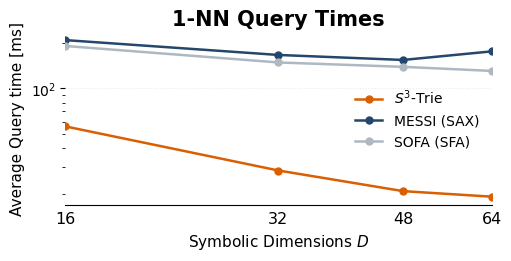

In [169]:
S3_TRIE = "$S^3$-Trie"

# Map your actual method names here
method_labels = {
    "MESSI / SAX": "MESSI (SAX)",
    "SOFA / SFA": "SOFA (SFA)",
    "TRIE / SPARTAN": S3_TRIE,
}

summary_plot = summary.copy()
summary_plot["method_label"] = summary_plot["method"].map(method_labels)

# Only keep requested segment counts
summary_plot = summary_plot[
    summary_plot["segments"].isin(n_segments)
].copy()

methods = summary_plot["method_label"].dropna().unique()


colors = {
    method: (
        "#d95f02" if method == S3_TRIE
        else "#24476b" if method == "MESSI (SAX)"
        else "#aeb8c2"
    )
    for method in methods
}


fig, ax = plt.subplots(figsize=(5.0, 2.5))

for method, group in summary_plot.groupby("method_label", sort=True):
    group = group.sort_values("segments")

    ax.plot(
        group["segments"],
        group["query_ms_mean"],
        marker="o",
        markersize=5,
        linewidth=1.8,
        color=colors[method],
        label=method,
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_locator(FixedLocator(n_segments))
ax.xaxis.set_major_formatter(
    FixedFormatter([str(x) for x in n_segments])
)

ax.xaxis.set_minor_locator(NullLocator())

ax.set_xlim(min(n_segments), max(n_segments))

ax.set_title(
    "1-NN Query Times",
    fontsize=15,
    fontweight="bold",
    pad=5,
)

ax.set_xlabel(
    "Symbolic Dimensions $D$",
    fontsize=11,
)

ax.set_ylabel(
    "Average Query time [ms]",
    fontsize=11,
)

ax.grid(
    axis="y",
    which="major",
    linestyle=":",
    linewidth=0.8,
    alpha=0.25,
)
ax.set_axisbelow(True)

ax.tick_params(
    axis="x",
    length=0,
    labelsize=11.5,
    pad=5,
)

ax.tick_params(
    axis="y",
    labelsize=10,
)

ax.legend(
    frameon=False,
    fontsize=10,
)

sns.despine(
    ax=ax,
    top=True,
    right=True,
    left=True,
)

fig.tight_layout(pad=0.3)

fig.savefig(
    "images/segment_scaling_lineplot.pdf",
    bbox_inches="tight",
)

plt.show()

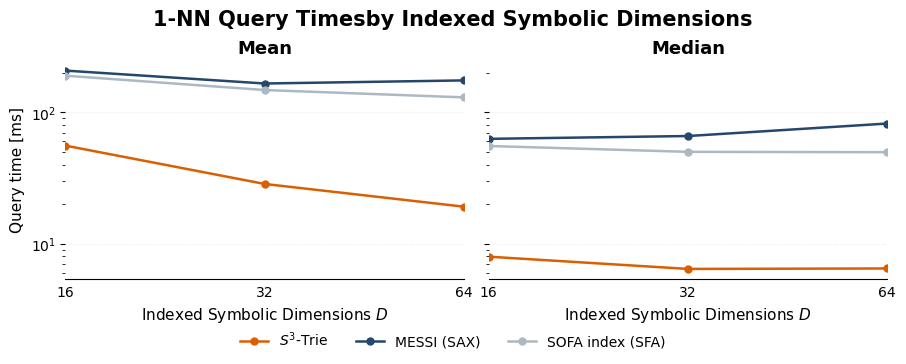

In [157]:
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator

S3_TRIE = "$S^3$-Trie"

method_labels = {
    "MESSI / SAX": "MESSI (SAX)",
    "SOFA / SFA": "SOFA index (SFA)",
    "TRIE / SPARTAN": S3_TRIE,
}

summary_plot = summary.copy()
summary_plot["method_label"] = summary_plot["method"].map(method_labels)

# Only selected segment counts
summary_plot = summary_plot[
    summary_plot["segments"].isin(n_segments)
].copy()

methods = summary_plot["method_label"].dropna().unique()

colors = {
    method: (
        "#d95f02" if method == S3_TRIE
        else "#24476b" if method == "MESSI (SAX)"
        else "#aeb8c2"
    )
    for method in methods
}


fig, axes = plt.subplots(
    1, 2,
    figsize=(9.0, 3.5),
    sharex=True,
    sharey=True,
)

panels = [
    ("query_ms_mean", "Mean"),
    ("query_ms_median", "Median"),
]

for ax, (metric, title) in zip(axes, panels):

    for method, group in summary_plot.groupby("method_label", sort=True):
        group = group.sort_values("segments")

        ax.plot(
            group["segments"],
            group[metric],
            marker="o",
            markersize=5,
            linewidth=1.8,
            color=colors[method],
            label=method,
        )

    # Log-log
    ax.set_xscale("log")
    ax.set_yscale("log")

    # Only show actual n_segments values
    ax.xaxis.set_major_locator(FixedLocator(n_segments))
    ax.xaxis.set_major_formatter(
        FixedFormatter([str(x) for x in n_segments])
    )
    ax.xaxis.set_minor_locator(NullLocator())

    ax.set_xlim(min(n_segments), max(n_segments))

    ax.set_title(
        title,
        fontsize=13,
        fontweight="bold",
        pad=5,
    )

    ax.set_xlabel(
        "Indexed Symbolic Dimensions $D$",
        fontsize=11,
    )

    ax.grid(
        axis="y",
        which="major",
        linestyle=":",
        linewidth=0.8,
        alpha=0.25,
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        axis="x",
        length=0,
        labelsize=10,
        pad=5,
    )

    ax.tick_params(
        axis="y",
        labelsize=10,
    )

    sns.despine(
        ax=ax,
        top=True,
        right=True,
        left=True,
    )


axes[0].set_ylabel(
    "Query time [ms]",
    fontsize=11,
)

# One legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=False,
    fontsize=10,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.11),
    ncol=len(labels),
)

fig.suptitle(
    "1-NN Query Timesby Indexed Symbolic Dimensions",
    fontsize=15,
    fontweight="bold",
    y=0.99,
)

fig.tight_layout(pad=0.5)
fig.subplots_adjust(bottom=0.22)

fig.savefig(
    "images/segment_scaling_mean_median.pdf",
    bbox_inches="tight",
)

plt.show()